In [1]:
import pickle
import re 
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
import os
import joypy

import scipy.stats as sstat
ZZ = sstat.norm.ppf

import mz_Lick_functions as mz_Lick

%matplotlib inline
%load_ext autoreload
%autoreload 2
mpl.rcParams['pdf.fonttype'] = 42 
mpl.rcParams['font.sans-serif']=['Arial', 'Helvetica','Bitstream Vera Sans', 'DejaVu Sans', 'Lucida Grande', 
                                 'Verdana', 'Geneva', 'Lucid', 'Avant Garde', 'sans-serif']  

sns.despine()

<Figure size 432x288 with 0 Axes>

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
        'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
        'axes.linewidth':2.5, 'lines.linewidth': 2.5,
        'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black',
        'axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

set_pub_plots()

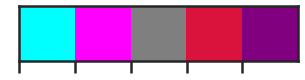

In [3]:
pal=sns.blend_palette(['cyan', 'magenta','gray','crimson','purple'], 5)
sns.palplot(pal)
sns.set_palette(pal)

---

# Define universal variables first

In [4]:
# u = start of trial
# m = no licks
# r = timestamp of reward
# z = rew2 stimulus
# o = unrew stimulus
# r, z, and o happen after the delay after the stimulus ends (1-sec or 2-sec)

interval = 1.0 # 1 second or 2 seconds depending on the training stage
stim_dur = 0.2
inter_dur = interval+stim_dur

rewarded_trials = 100
unrew_trials = 50
rew_trials = 80
rew2_trials = 20

In [5]:
#Psuedo random presentation of the stimuli - 25 per row * 6 rows = 150 trials
# 0 -- drifting grating, rewarded stimulus, 100 trials
# 1 -- pink noise, unrewarded stimulus, 50 trials
stim_order = [0,1,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,
               0,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,1,0,0,0,0,1,
               0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,1,0,1,0,0,0,0,1,
               0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,
               1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0,1,1,0,0,
               0,0,1,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,0]

#Psuedo random distribution of water to the rewarded stimuli
# 0 -- water given -- 80 times
# 1 -- no water given -- 20 times
rew_order = [0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,
               0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,
               0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,
               0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0]

overall_order = []
i=0
for idx,val in enumerate(stim_order):
    if val == 0:
        i = i+1
        if rew_order[i-1] == 0:
            overall_order.append('0') # rewH20
        elif rew_order[i-1] == 1:
            overall_order.append('1') # rewnoH20
    elif val == 1:
        overall_order.append('2')     # unrew
print(len(overall_order))

150


---

# All mice across all days

In [13]:
path = r"C:\Users\AChub_Lab\Desktop\lick_days" #pre-selected ones copied to desktop

# other options, from the start of training, are 'pav_' and 'interval_'
paradigm = "oper_disc_"

matches = []
for root, dirnames, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith(('.pkl')) and "bad" not in filename and "bad" not in root and paradigm in filename:
            matches.append(os.path.join(root, filename))
print ("# of file matches:", len(matches))

# matches[0]

# of file matches: 70


### Important note!
if files dont load below, its more than likely bc they are not a full 150 trials...

In [14]:
count = 0
ls = []
for fn in matches[:]:
    try:
        df = mz_Lick.new_get_licks_df(fn, overall_order, inter_dur) #function that calls main 3 functions
        
        base = fn.split("\\")[-1]
        cc = base.split("_")[0]
        hp =  base.split("_")[1]
        paradigm = base.split('_')[2]
        date = base.split('_')[-2]

        df['et'] = str(cc) + '_' + str(hp)
        df['cc'] = str(cc)
        df['paradigm'] = paradigm
        df['date'] = date

        ls.append(df)

    except:
        print ("not loaded:", fn)
        count += 1
        
main_df = pd.concat(ls)
print('***** {0} out of {1} files not loaded'.format(count,len(matches)))

***** 0 out of 70 files not loaded


In [16]:
main_df.head()

,trial,lick_idx,lick_time,stim_id,et,cc,paradigm,date
0,1,0,-1.930008,rew,CC067431_HP1,CC067431,oper,2021-07-08
1,1,1,-1.870010,rew,CC067431_HP1,CC067431,oper,2021-07-08
2,1,2,-1.050003,rew,CC067431_HP1,CC067431,oper,2021-07-08
3,1,3,-0.890007,rew,CC067431_HP1,CC067431,oper,2021-07-08
4,1,4,-0.830009,rew,CC067431_HP1,CC067431,oper,2021-07-08


Need to do:
1. Add group label column to main_df above
2. Separate main_df into situations (rew, rew2, unrew) using the "stim_id" label present
3. sns.histplot these three new dfs where data=situation_df, x="lick_time", hue="group"
    - adjust this with either bins= or binwidth=

In [9]:
if (cc == "CC082263") | (cc == "CC067489") | (cc == "CC082260") | (cc == "CC084621"):
    mouse_type = 'WT'
    plt_color = 'blue' # cyan or blue
elif (cc == "CC082257") | (cc == "CC067431") | (cc == "CC067432") | (cc == "CC082255"):
    mouse_type = 'FX'
    plt_color = 'purple' # magenta or purple
else:
    raise ValueError('Incorrect path, check the code...')

---

# plot the histograms!

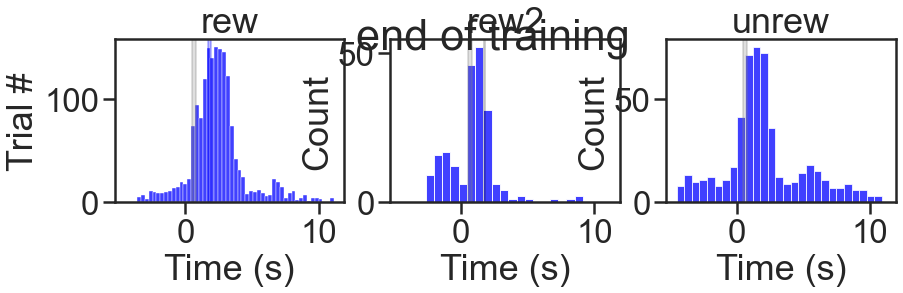

In [12]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 14.0 # x dimension
fig_size[1] = 3 # y dimension
plt.suptitle('end of training')

ax1 = plt.subplot(131)
sns.histplot(x_plt1, color=plt_color)
plt.axvspan(0.5,0.8, color='grey', alpha=0.25)
plt.axvspan(1.7,1.9, color='blue', alpha=0.25)
plt.title(title1)
plt.xlabel('Time (s)')
plt.ylabel('Trial #')

ax2 = plt.subplot(132, sharex=ax1)
sns.histplot(x_plt2, color=plt_color)
plt.axvspan(0.5,0.8, color='grey', alpha=0.25)
plt.axvline(1.7, color='black', alpha=0.25)
plt.title(title2)
plt.xlabel('Time (s)')

ax3 = plt.subplot(133, sharex=ax1)
sns.histplot(x_plt3, color=plt_color)
plt.axvspan(0.5,0.8, color='grey', alpha=0.25)
plt.title(title3)
plt.xlabel('Time (s)')

# Change the end of this next line with a new file name!!
# plt.savefig(r"C:\Users\AChub_Lab\Desktop\lick_days\raster_WT_end.pdf", transparent=True)

plt.show()